<h2 style="color: blue;">🩺 Patient Health Records EDA: Diagnoses, BMI & Cholesterol Trends</h2>
<p>This project explores a synthetic healthcare dataset using Python and pandas. The data is loaded, cleaned, and analyzed, then visualized to uncover patterns across diagnosis, age, gender, and treatment plans.</p>

<h4 style="color: blue;">Import data libraries and load dataset</h4>

In [1]:
# Data imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
sns.set_palette("Set2")
plt.rcParams["figure.dpi"] = 100

# Load dataset
df = pd.read_csv("healthcare_dataset.csv")
df.head()

,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
0,1,51,Female,97,90,282,35.2,Hypertension,Observation,2024-01-01
1,2,92,Other,129,80,169,32.3,Healthy,Medication,2024-01-02
2,3,14,Male,172,76,157,29.9,Diabetes,Observation,2024-01-03
3,4,71,Female,131,82,150,19.4,Coronary Artery Disease,Surgery,2024-01-04
4,5,60,Male,130,96,206,39.3,Diabetes,NaN,2024-01-05


<h4 style="color: blue;">Data inspection</h4>

In [2]:
# General info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         500 non-null    int64  
 1   Age                500 non-null    int64  
 2   Gender             500 non-null    object 
 3   Blood_Pressure     500 non-null    int64  
 4   Heart_Rate         500 non-null    int64  
 5   Cholesterol_Level  500 non-null    int64  
 6   BMI                500 non-null    float64
 7   Diagnosis          500 non-null    object 
 8   Treatment_Plan     405 non-null    object 
 9   Follow_Up_Date     500 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 39.2+ KB


In [3]:
# Statistics (numeric columns)
df.describe()

,Patient_ID,Age,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,48.87400,133.024000,79.874000,225.806000,29.430400
std,144.481833,29.56983,25.665246,11.354293,44.964608,6.132838
min,1.000000,0.00000,90.000000,60.000000,150.000000,18.600000
25%,125.750000,23.00000,112.000000,70.750000,186.000000,24.100000
50%,250.500000,50.00000,132.000000,79.500000,226.000000,29.600000
75%,375.250000,72.25000,154.000000,90.000000,267.000000,34.725000
max,500.000000,99.00000,179.000000,99.000000,299.000000,40.000000


In [4]:
# Statistics (categorical columns)
df.describe(include='object')

,Gender,Diagnosis,Treatment_Plan,Follow_Up_Date
count,500,500,405,500
unique,3,5,4,500
top,Male,Healthy,Medication,2024-01-01
freq,187,104,109,1


<h4 style="color: blue;">Data quality check</h4>

In [5]:
# Missing values
print("Missing values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Duplicate Patient IDs
print("Duplicate Patient_IDs:", df['Patient_ID'].duplicated().sum())

Missing values:
Patient_ID            0
Age                   0
Gender                0
Blood_Pressure        0
Heart_Rate            0
Cholesterol_Level     0
BMI                   0
Diagnosis             0
Treatment_Plan       95
Follow_Up_Date        0
dtype: int64

Duplicate rows: 0
Duplicate Patient_IDs: 0


In [6]:
# Check for implausible values
print("Age range:", df['Age'].min(), "-", df['Age'].max())
print("Blood_Pressure range:", df['Blood_Pressure'].min(), "-", df['Blood_Pressure'].max())
print("Heart_Rate range:", df['Heart_Rate'].min(), "-", df['Heart_Rate'].max())
print("Cholesterol_Level range:", df['Cholesterol_Level'].min(), "-", df['Cholesterol_Level'].max())
print("BMI range:", df['BMI'].min(), "-", df['BMI'].max())

Age range: 0 - 99
Blood_Pressure range: 90 - 179
Heart_Rate range: 60 - 99
Cholesterol_Level range: 150 - 299
BMI range: 18.6 - 40.0


<h4 style="color: blue;">Cleaning and Preprocessing</h4>

In [7]:
# Flag rows with Age = 0
age_zero = df[df['Age'] == 0]
print("Rows with Age = 0:", len(age_zero))
age_zero.head()

Rows with Age = 0: 9


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Cholesterol_Level,BMI,Diagnosis,Treatment_Plan,Follow_Up_Date
112,113,0,Male,124,85,248,35.8,Hypertension,Surgery,2024-04-22
146,147,0,Other,96,74,170,19.1,Hypertension,Lifestyle Changes,2024-05-26
192,193,0,Female,109,69,158,27.3,Hypertension,Observation,2024-07-11
230,231,0,Other,143,91,267,38.8,Hyperlipidemia,Observation,2024-08-18
274,275,0,Other,111,79,185,32.1,Hyperlipidemia,NaN,2024-10-01


In [8]:
# Flag valid vs invalid age count
df['Age_Flag'] = np.where(df['Age'] == 0, 'Invalid', 'Valid')
print(df['Age_Flag'].value_counts())

Age_Flag
Valid      491
Invalid      9
Name: count, dtype: int64


In [9]:
# Fill missing Treatment_Plan
df['Treatment_Plan'] = df['Treatment_Plan'].fillna('Unknown')

# Confirm missing count
print(df.isnull().sum())

Patient_ID           0
Age                  0
Gender               0
Blood_Pressure       0
Heart_Rate           0
Cholesterol_Level    0
BMI                  0
Diagnosis            0
Treatment_Plan       0
Follow_Up_Date       0
Age_Flag             0
dtype: int64


In [10]:
# Convert data types
df['Gender'] = df['Gender'].astype('category')
df['Diagnosis'] = df['Diagnosis'].astype('category')
df['Treatment_Plan'] = df['Treatment_Plan'].astype('category')
df['Follow_Up_Date'] = pd.to_datetime(df['Follow_Up_Date'])

In [11]:
# Create age groups
bins = [0, 29, 44, 59, 74, 100]
labels = ['<30', '30-44', '45-59', '60-74', '75+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Confirm new data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Patient_ID         500 non-null    int64         
 1   Age                500 non-null    int64         
 2   Gender             500 non-null    category      
 3   Blood_Pressure     500 non-null    int64         
 4   Heart_Rate         500 non-null    int64         
 5   Cholesterol_Level  500 non-null    int64         
 6   BMI                500 non-null    float64       
 7   Diagnosis          500 non-null    category      
 8   Treatment_Plan     500 non-null    category      
 9   Follow_Up_Date     500 non-null    datetime64[ns]
 10  Age_Flag           500 non-null    object        
 11  Age_Group          491 non-null    category      
dtypes: category(4), datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 34.1+ KB


<h4 style="color: blue;">Univariate Analysis</h4>

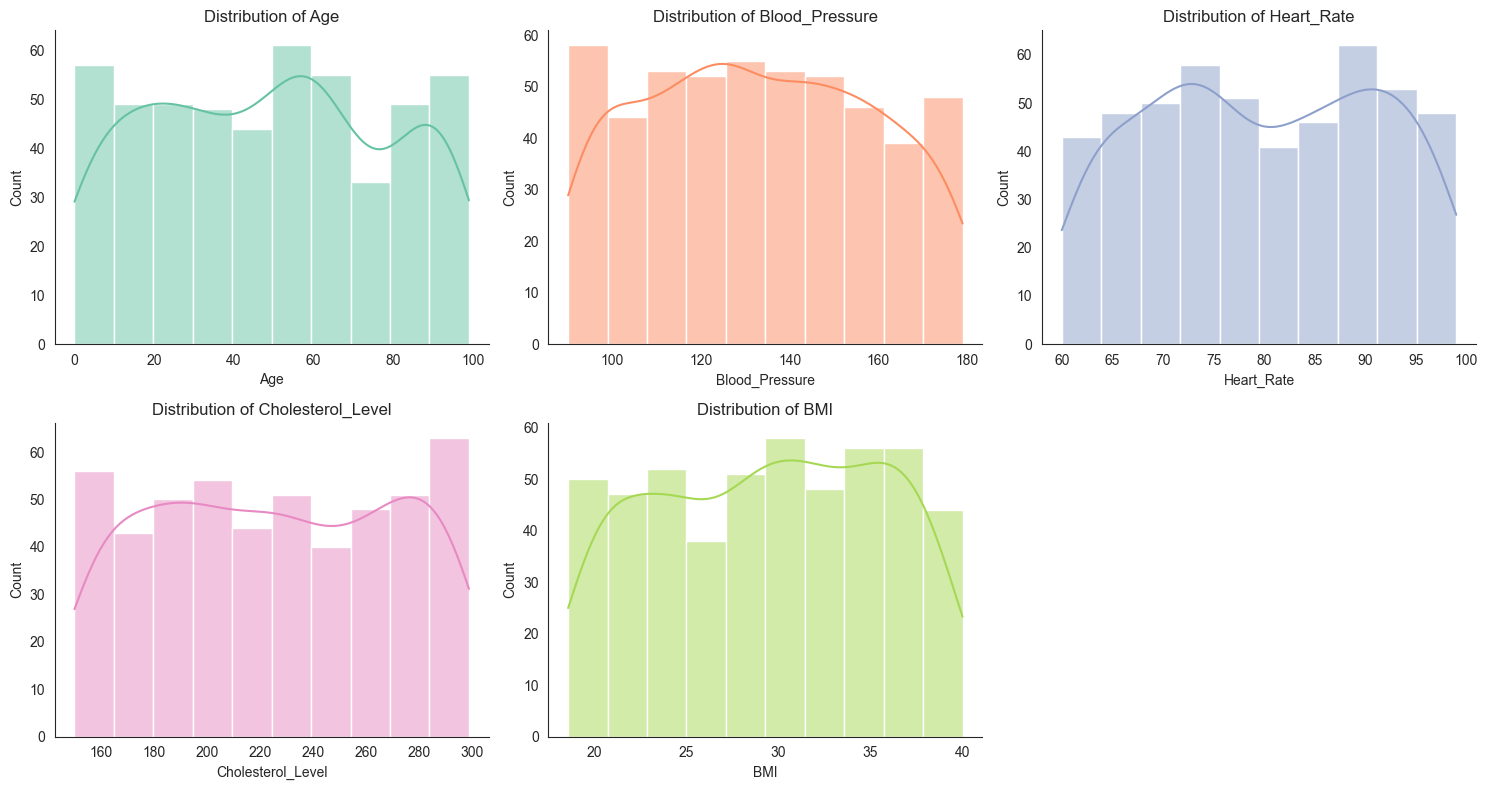

In [12]:
# Numeric distributions
numeric_cols = ['Age', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']
palette_colors = sns.color_palette("Set2", len(numeric_cols))

fig_numeric, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=palette_colors[i])
    axes[i].set_title(f'Distribution of {col}')
    sns.despine(ax=axes[i])

fig_numeric.delaxes(axes[5])
plt.tight_layout()
plt.show()

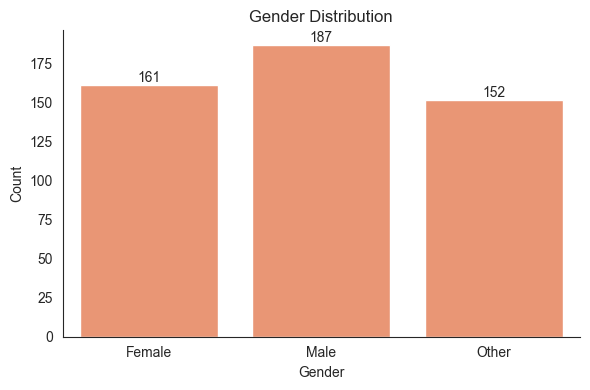

In [13]:
# Gender distribution
fig_gender, ax_gender = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Gender', ax=ax_gender, color=sns.color_palette("Set2")[1])
ax_gender.set_title('Gender Distribution')
ax_gender.set_xlabel('Gender')
ax_gender.set_ylabel('Count')

for container in ax_gender.containers:
    ax_gender.bar_label(container)

sns.despine(ax=ax_gender)
plt.tight_layout()
plt.show()

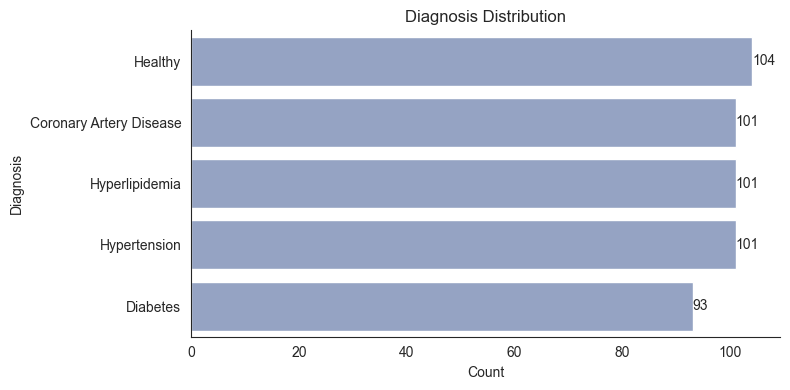

In [14]:
# Diagnosis distribution
fig_diag, ax_diag = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, y='Diagnosis', order=df['Diagnosis'].value_counts().index,
              ax=ax_diag, color=sns.color_palette("Set2")[2])
ax_diag.set_title('Diagnosis Distribution')
ax_diag.set_xlabel('Count')
ax_diag.set_ylabel('Diagnosis')

for container in ax_diag.containers:
    ax_diag.bar_label(container)

sns.despine(ax=ax_diag)
plt.tight_layout()
plt.show()

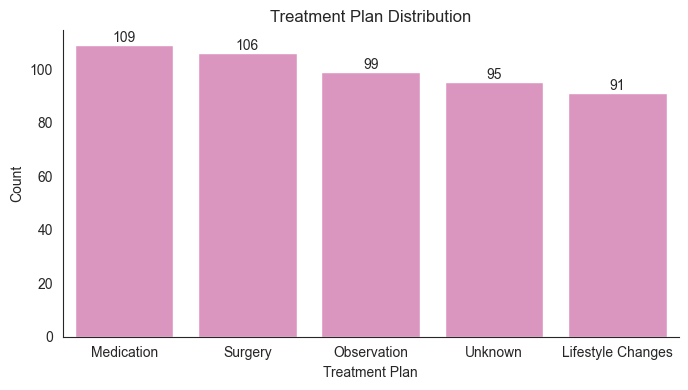

In [15]:
# Treatment Plan distribution
fig_treat, ax_treat = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Treatment_Plan', order=df['Treatment_Plan'].value_counts().index,
              ax=ax_treat, color=sns.color_palette("Set2")[3])
ax_treat.set_title('Treatment Plan Distribution')
ax_treat.set_xlabel('Treatment Plan')
ax_treat.set_ylabel('Count')
plt.xticks(rotation=0)

for container in ax_treat.containers:
    ax_treat.bar_label(container)

sns.despine(ax=ax_treat)
plt.tight_layout()
plt.show()

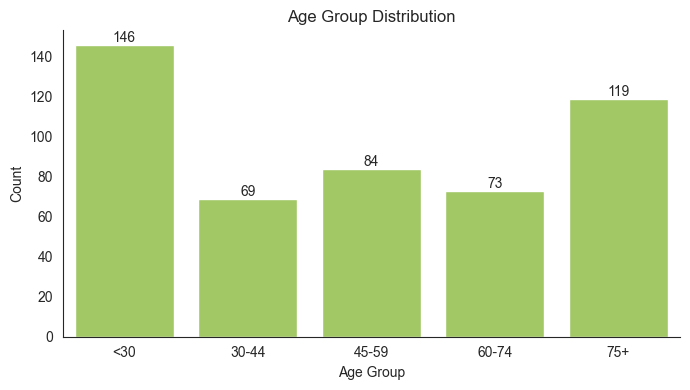

In [16]:
# Age Group distribution
fig_agegrp, ax_agegrp = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x='Age_Group', order=['<30', '30-44', '45-59', '60-74', '75+'],
              ax=ax_agegrp, color=sns.color_palette("Set2")[4])
ax_agegrp.set_title('Age Group Distribution')
ax_agegrp.set_xlabel('Age Group')
ax_agegrp.set_ylabel('Count')

for container in ax_agegrp.containers:
    ax_agegrp.bar_label(container)

sns.despine(ax=ax_agegrp)
plt.tight_layout()
plt.show()

<h4 style="color: blue;">Bivariate & Multivariate Analysis</h4>

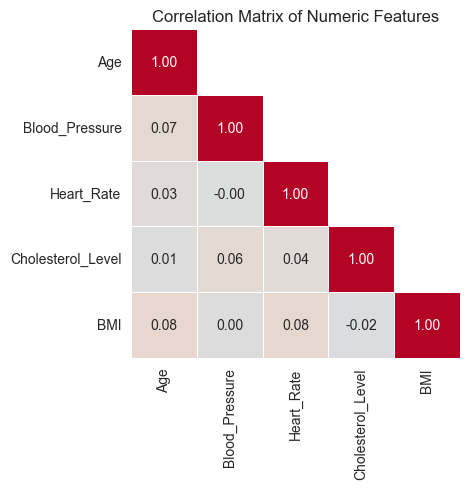

In [17]:
# Correlation heatmap (numeric features)
fig_corr, ax_corr = plt.subplots(figsize=(7, 5))
corr_matrix = df[['Age', 'Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar=False, ax=ax_corr)

ax_corr.set_title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

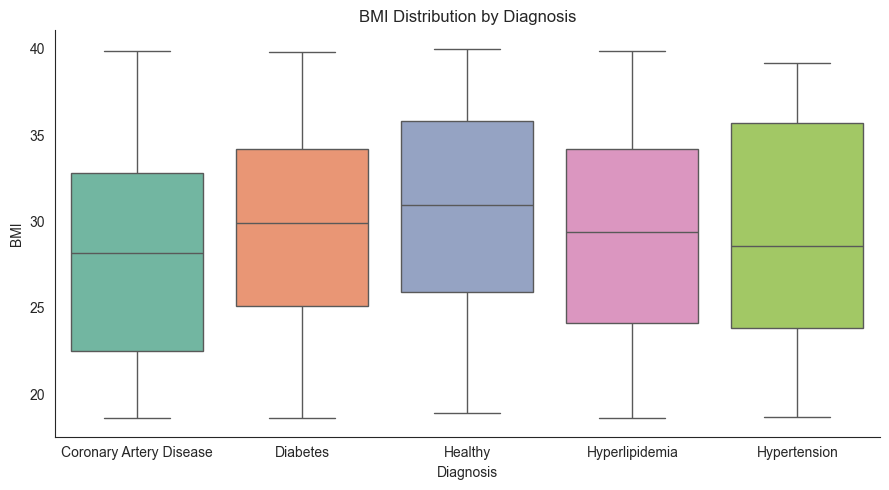

In [18]:
# BMI by Diagnosis
fig_bmi_box, ax_bmi_box = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Diagnosis', y='BMI',
            hue='Diagnosis', palette='Set2',
            legend=False, ax=ax_bmi_box)
ax_bmi_box.set_title('BMI Distribution by Diagnosis')
ax_bmi_box.set_xlabel('Diagnosis')
ax_bmi_box.set_ylabel('BMI')
plt.xticks(rotation=0)
sns.despine(ax=ax_bmi_box)
plt.tight_layout()
plt.show()

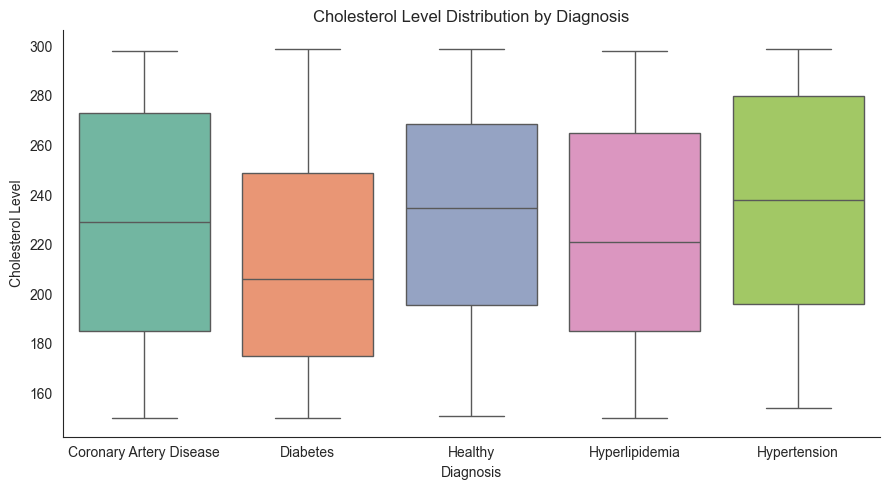

In [19]:
# Cholesterol by Diagnosis
fig_chol_box, ax_chol_box = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Diagnosis', y='Cholesterol_Level',
            hue='Diagnosis', palette='Set2',
            legend=False, ax=ax_chol_box)
ax_chol_box.set_title('Cholesterol Level Distribution by Diagnosis')
ax_chol_box.set_xlabel('Diagnosis')
ax_chol_box.set_ylabel('Cholesterol Level')
plt.xticks(rotation=0)
sns.despine(ax=ax_chol_box)
plt.tight_layout()
plt.show()

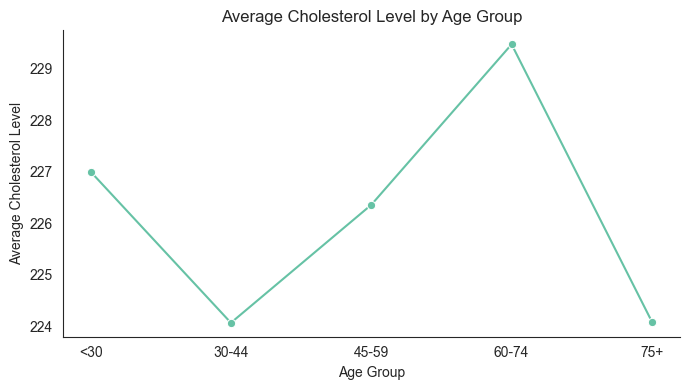

In [20]:
# Cholesterol by Age Group (line trend)
cholesterol_by_age = df.groupby('Age_Group', observed=True)['Cholesterol_Level'].mean().reset_index()

fig_chol_line, ax_chol_line = plt.subplots(figsize=(7, 4))
sns.lineplot(data=cholesterol_by_age, x='Age_Group', y='Cholesterol_Level',
             marker='o', ax=ax_chol_line, color=sns.color_palette("Set2")[0])
ax_chol_line.set_title('Average Cholesterol Level by Age Group')
ax_chol_line.set_xlabel('Age Group')
ax_chol_line.set_ylabel('Average Cholesterol Level')
sns.despine(ax=ax_chol_line)
plt.tight_layout()
plt.show()

In [21]:
# Gender vs Diagnosis crosstab
diagnosis_by_gender = pd.crosstab(df['Gender'], df['Diagnosis']).T
print(diagnosis_by_gender)

Gender                   Female  Male  Other
Diagnosis                                   
Coronary Artery Disease      31    37     33
Diabetes                     28    39     26
Healthy                      33    33     38
Hyperlipidemia               28    45     28
Hypertension                 41    33     27


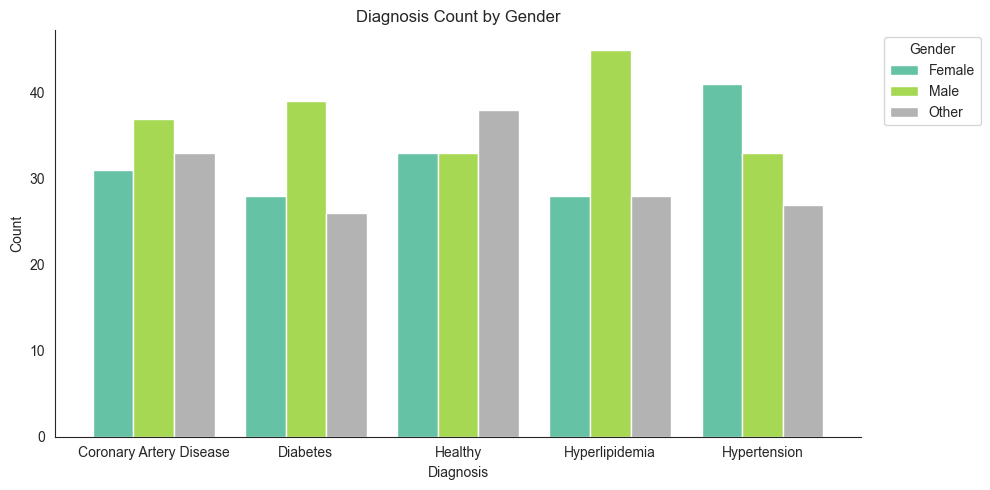

In [22]:
# Gender vs Diagnosis
diagnosis_by_gender_t = pd.crosstab(df['Diagnosis'], df['Gender'])

fig_gender_diag, ax_gender_diag = plt.subplots(figsize=(10, 5))
diagnosis_by_gender_t.plot(kind='bar', ax=ax_gender_diag, width=0.8, colormap='Set2')
ax_gender_diag.set_title('Diagnosis Count by Gender')
ax_gender_diag.set_xlabel('Diagnosis')
ax_gender_diag.set_ylabel('Count')
plt.xticks(rotation=0)
ax_gender_diag.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine(ax=ax_gender_diag)
plt.tight_layout()
plt.show()

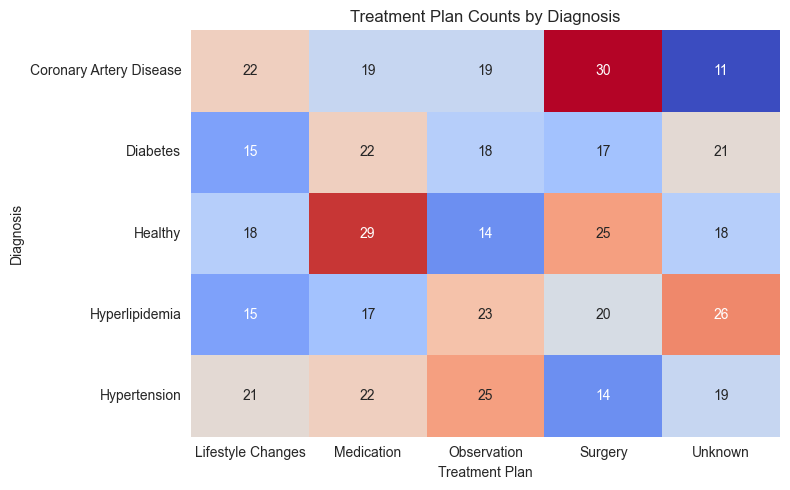

In [23]:
# Treatment Plan by Diagnosis (heatmap)
treatment_by_diagnosis = pd.crosstab(df['Diagnosis'], df['Treatment_Plan'])

fig_treat_diag, ax_treat_diag = plt.subplots(figsize=(8, 5))
sns.heatmap(treatment_by_diagnosis, annot=True, cbar=False, fmt='d', cmap='coolwarm', ax=ax_treat_diag)
ax_treat_diag.set_title('Treatment Plan Counts by Diagnosis')
ax_treat_diag.set_xlabel('Treatment Plan')
ax_treat_diag.set_ylabel('Diagnosis')
plt.tight_layout()
plt.show()

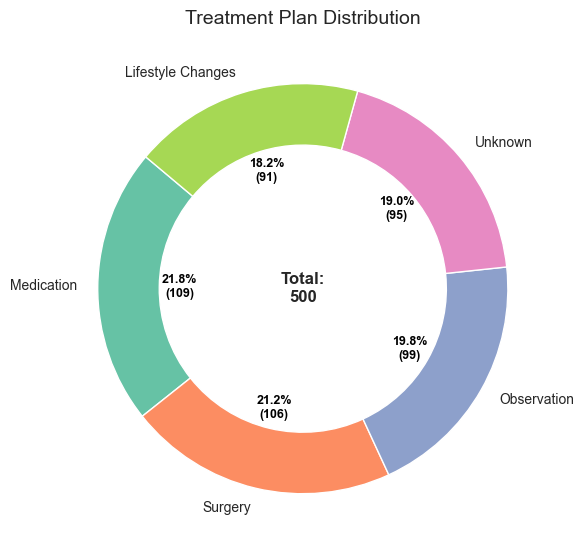

In [24]:
# Treatment Plan Distribution
treatment_counts = df['Treatment_Plan'].value_counts()

def format_label(pct, allvals):
    absolute = int(round(pct / 100. * sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"

fig_donut, ax_donut = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax_donut.pie(
    treatment_counts,
    labels=treatment_counts.index,
    autopct=lambda pct: format_label(pct, treatment_counts),
    startangle=140,
    colors=sns.color_palette("Set2", len(treatment_counts)),
    wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 1}
)

plt.setp(autotexts, size=9, weight='bold', color='black')
plt.setp(texts, size=10)

ax_donut.text(0, 0, f'Total:\n{treatment_counts.sum()}',
              horizontalalignment='center', verticalalignment='center',
              fontsize=12, fontweight='bold')
ax_donut.set_title('Treatment Plan Distribution', fontsize=14)
plt.tight_layout()
plt.show()

<h4 style="color: blue;">Outlier Detection</h4>

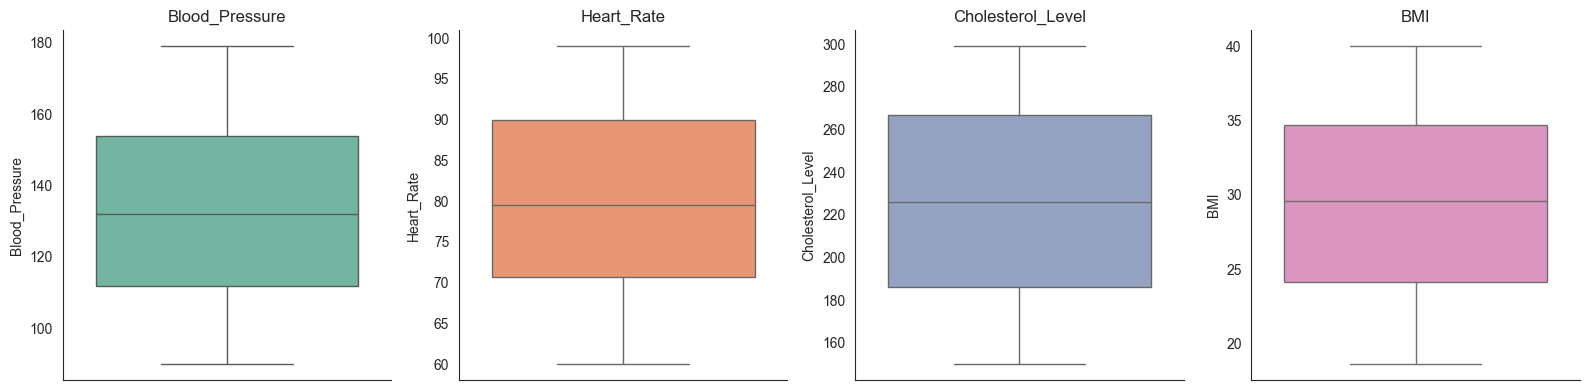

In [25]:
# Boxplots for outlier detection
outlier_cols = ['Blood_Pressure', 'Heart_Rate', 'Cholesterol_Level', 'BMI']

fig_outliers, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette("Set2")[i])
    axes[i].set_title(col)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

In [26]:
# IQR method: flag outliers
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_summary = {}
for col in outlier_cols:
    outlier_summary[col] = iqr_outliers(df[col]).sum()

print("Outlier counts (IQR method):")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

Outlier counts (IQR method):
Blood_Pressure: 0
Heart_Rate: 0
Cholesterol_Level: 0
BMI: 0


<h4 style="color: blue;">Summary & Insight</h4>

In [27]:
# Summary statistics by diagnosis
summary = df.groupby('Diagnosis', observed=True).agg({
    'Age': 'mean',
    'BMI': 'mean',
    'Cholesterol_Level': 'mean',
    'Patient_ID': 'count'
}).rename(columns={'Patient_ID': 'Patient_Count'})

summary = summary.round(1)
summary

,Age,BMI,Cholesterol_Level,Patient_Count
Diagnosis,,,,
Coronary Artery Disease,49.3,28.2,226.9,101
Diabetes,43.0,29.8,212.4,93
Healthy,53.6,30.4,230.3,104
Hyperlipidemia,48.9,29.5,224.0,101
Hypertension,49.0,29.2,234.2,101


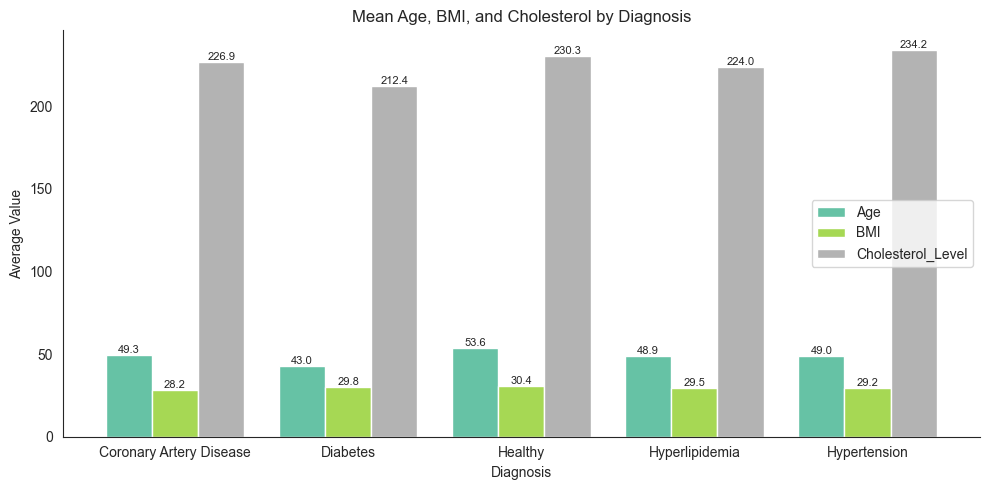

In [28]:
# Plot summary metrics by diagnosis
fig_summary, ax_summary = plt.subplots(figsize=(10, 5))
summary[['Age', 'BMI', 'Cholesterol_Level']].plot(kind='bar', ax=ax_summary, width=0.8, colormap='Set2')
ax_summary.set_title('Mean Age, BMI, and Cholesterol by Diagnosis')
ax_summary.set_ylabel('Average Value')
plt.xticks(rotation=0)

for container in ax_summary.containers:
    ax_summary.bar_label(container, fmt='%.1f', fontsize=8)

sns.despine(ax=ax_summary)
plt.tight_layout()
plt.show()

In [29]:
# Key insights:
# No strong correlations between vitals, BMI, cholesterol, or age - data likely synthetic
# Zero IQR outliers across all numeric fields supports this
# Diagnosis groups fairly even by gender; BMI/cholesterol similar across diagnoses
# Diabetes patients skew younger (43.0 avg) vs Healthy (53.6 avg)
# Treatment varies by diagnosis: CAD > Surgery, Hypertension > Observation
# 9 rows have Age = 0 (flagged, not dropped) - exclude from age-based analysis

In [30]:
# # Export cleaned dataset and summary table:
# df.to_csv("healthcare_dataset_cleaned.csv", index=False)
# summary.to_csv("diagnosis_summary.csv")
# print("Files exported.")